# ANÁLISIS DE CALIDAD DE DATOS - Registro Nacional de Municipalidades (RENAMU 2022)

---

## Contexto del Proyecto

### Descripción del Problema
El **Instituto Nacional de Estadística e Informática (INEI)**, a través del
Registro Nacional de Municipalidades (RENAMU 2022), recopila información
estructural y operativa de todas las municipalidades del Perú. Sin embargo,
al integrar este dataset con los datos de ingresos del SIAF y el SISMEPRE,
se detectan inconsistencias en los códigos de ubigeo, columnas con nombres
codificados (P04_1, P11A_2, etc.) sin descripción clara, valores faltantes
en campos clave, y problemas de encoding en el archivo fuente que dificultan
su uso directo en el análisis presupuestal.

### Objetivo Analítico
Evaluar y mejorar la calidad de los datos del RENAMU 2022 para:
- Garantizar que el Ubigeo permita el JOIN correcto con SIAF y SISMEPRE
- Seleccionar y validar las columnas relevantes para el análisis municipal
- Identificar municipalidades con información incompleta que afecte
  el análisis de capacidad institucional y recaudación
- Preparar el dataset como dimensión de municipalidad en el modelo estrella Gold

### Impacto de la Mala Calidad de Datos
- **Financiero**: Un Ubigeo mal formado impide relacionar el RENAMU con los
  montos del SIAF, perdiendo contexto institucional clave para el análisis
- **Operativo**: Columnas codificadas sin diccionario hacen imposible
  interpretar correctamente las variables de gestión municipal
- **Estratégico**: Decisiones de política pública basadas en datos incompletos
  del RENAMU pueden llevar a caracterizaciones incorrectas de las
  municipalidades y sus capacidades de recaudación

---

## Dimensiones de Calidad a Evaluar

En este caso trabajaremos con:

1. **Completitud**: ¿Tenemos datos de todas las municipalidades del país
   con sus campos clave completos?
2. **Exactitud**: ¿Los valores de Ubigeo, tipo de municipalidad y
   variables de gestión son correctos?
3. **Consistencia**: ¿Los campos de departamento, provincia y distrito
   son coherentes entre sí y con el Ubigeo?
4. **Integridad**: ¿El Ubigeo tiene el formato correcto para relacionarse
   con SIAF y SISMEPRE?
5. **Razonabilidad**: ¿Los valores numéricos de las variables de gestión
   están dentro de rangos esperados?
6. **Oportunidad**: ¿El dataset cubre todas las municipalidades del Perú
   registradas en 2022?
7. **Unicidad**: ¿Existen municipalidades duplicadas por Ubigeo o código?
8. **Validez**: ¿Los formatos de Ubigeo, tipo de municipalidad y
   códigos de departamento son correctos?

---

In [1]:
# Instalación de librerías necesarias
# !pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print(" Librerías cargadas correctamente")
print(f" Análisis ejecutado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 Librerías cargadas correctamente
 Análisis ejecutado: 2026-05-21 22:52:18


## Carga del Dataset

Cargaremos el dataset RENAMU 2022 con 1,874 municipalidades y 1,368 columnas.

In [ ]:
# Cargar datos desde el archivo CSV
# Nota: el RENAMU usa separador punto y coma (;) y encoding utf-8-sig
# para conservar correctamente caracteres como Año y Nº.
df = pd.read_csv(
    'Base_RENAMU_2022_f.csv',
    sep=';',
    encoding='utf-8-sig',
    low_memory=False
)

# Limpiar nombres de columnas y asegurar nombre estándar para la columna de año
df.columns = df.columns.str.strip()
df = df.rename(columns={df.columns[0]: 'Año'})

print(f"Dataset cargado correctamente")
print(f"Total de registros  : {len(df):,}")
print(f"Total de columnas   : {len(df.columns)}")
print(f"Año del registro    : {df['Año'].unique()}")
print(f"Departamentos únicos: {df['Departamento'].nunique()}")
print(f"Municipalidades     : {len(df):,}")
print(f"\nColumnas clave disponibles:")
cols_clave = ['Año', 'Ubigeo', 'Departamento', 'Provincia', 'Distrito', 'Tipomuni']
for col in cols_clave:
    print(f"{col}" if col in df.columns else f"   ❌ {col} — NO ENCONTRADA")

Dataset cargado correctamente
Total de registros  : 1,874
Total de columnas   : 1368
Año del registro    : [2022]
Departamentos únicos: 25
Municipalidades     : 1,874

Columnas clave disponibles:
   ✅ Año
   ✅ Ubigeo
   ✅ Departamento
   ✅ Provincia
   ✅ Distrito
   ✅ Tipomuni


In [3]:
# Vista previa del dataset
df.head(10)

,Año,idmunici,ccdd,ccpp,ccdi,Ubigeo,Departamento,Provincia,Distrito,Tipomuni,...,C97_2_2_3_6,C97_2_2_3_7,C97_2_2_3_8,C97_2_2_3_9,C97_2_2_3_10,C97_2_2_3_11,C97_2_2_4,C97_2_3,C97_2_4,C97_3
0,2022,10101,1,1,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1,...,"180839,86","4282884,66",0,0,"363709,19",0,"1215916,85",0,0,0
1,2022,10102,1,1,2,10102,AMAZONAS,CHACHAPOYAS,ASUNCION,2,...,0,155045,0,0,79550,0,"58243,34",0,0,0
2,2022,10103,1,1,3,10103,AMAZONAS,CHACHAPOYAS,BALSAS,2,...,0,0,0,0,0,0,132800,0,0,0
3,2022,10104,1,1,4,10104,AMAZONAS,CHACHAPOYAS,CHETO,2,...,0,"187296,37",0,0,0,0,"133309,38",0,0,0
4,2022,10105,1,1,5,10105,AMAZONAS,CHACHAPOYAS,CHILIQUIN,2,...,0,316713,0,0,0,0,73825,0,0,0
5,2022,10106,1,1,6,10106,AMAZONAS,CHACHAPOYAS,CHUQUIBAMBA,2,...,0,0,"85348,72",0,0,0,"474378,51",0,0,0
6,2022,10107,1,1,7,10107,AMAZONAS,CHACHAPOYAS,GRANADA,2,...,0,"365579,11",0,63037,0,0,75260,0,0,0
7,2022,10108,1,1,8,10108,AMAZONAS,CHACHAPOYAS,HUANCAS,2,...,0,"121356,2",0,0,"47209,71",0,41000,0,0,0
8,2022,10109,1,1,9,10109,AMAZONAS,CHACHAPOYAS,LA JALCA,2,...,0,"384534,15","276900,45",0,"406576,6",0,"139273,43",0,0,0
9,2022,10110,1,1,10,10110,AMAZONAS,CHACHAPOYAS,LEIMEBAMBA,2,...,0,"269907,8",0,14170,0,0,"489464,73",0,0,0


In [4]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1874 entries, 0 to 1873
Columns: 1368 entries, Año to C97_3
dtypes: int64(539), object(829)
memory usage: 19.6+ MB


---

## Análisis de Calidad de Datos

### 1. COMPLETITUD - Análisis de Datos Faltantes

In [5]:
# Calcular porcentaje de valores faltantes
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

# Crear DataFrame con resultados
completitud = pd.DataFrame({
    'Faltantes': missing_data,
    'Porcentaje': missing_percent
}).sort_values('Porcentaje', ascending=False)

print("ANÁLISIS DE COMPLETITUD")
print(completitud[completitud['Faltantes'] > 0])

# Visualización
faltantes = completitud[completitud['Porcentaje'] > 0]
if len(faltantes) > 0:
    plt.figure(figsize=(10, 6))
    faltantes.plot(kind='bar', y='Porcentaje')
    plt.title('Porcentaje de Datos Faltantes por Columna')
    plt.ylabel('Porcentaje (%)')
    plt.xlabel('Columnas')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron valores faltantes en el dataset.")

ANÁLISIS DE COMPLETITUD
Empty DataFrame
Columns: [Faltantes, Porcentaje]
Index: []
No se encontraron valores faltantes en el dataset.


### 2. EXACTITUD - Validación de Valores Numéricos

In [6]:
# Validar códigos geográficos y tipo de municipalidad
ubigeo_str = df['Ubigeo'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(6)
ubigeos_longitud_invalida = df[ubigeo_str.str.len() != 6]
ubigeos_no_numericos = df[~ubigeo_str.str.match(r'^\d{6}$')]

# Validar rangos básicos de códigos INEI
ccdd_invalidos = df[(df['ccdd'] < 1) | (df['ccdd'] > 25)]
ccpp_invalidos = df[(df['ccpp'] < 1) | (df['ccpp'] > 99)]
ccdi_invalidos = df[(df['ccdi'] < 1) | (df['ccdi'] > 99)]
tipomuni_invalidos = df[~df['Tipomuni'].isin([1, 2])]

print("ANÁLISIS DE EXACTITUD")

print(f"Ubigeos con longitud inválida: {len(ubigeos_longitud_invalida):,} ({len(ubigeos_longitud_invalida)/len(df)*100:.2f}%)")
print(f"Ubigeos no numéricos: {len(ubigeos_no_numericos):,} ({len(ubigeos_no_numericos)/len(df)*100:.2f}%)")
print(f"Departamentos fuera de rango: {len(ccdd_invalidos):,} ({len(ccdd_invalidos)/len(df)*100:.2f}%)")
print(f"Provincias fuera de rango: {len(ccpp_invalidos):,} ({len(ccpp_invalidos)/len(df)*100:.2f}%)")
print(f"Distritos fuera de rango: {len(ccdi_invalidos):,} ({len(ccdi_invalidos)/len(df)*100:.2f}%)")
print(f"Tipomuni inválidos: {len(tipomuni_invalidos):,} ({len(tipomuni_invalidos)/len(df)*100:.2f}%)")

# Mostrar ejemplos
print("\nEjemplos de errores:")
print("\nUbigeos con formato inválido:")
print(df.loc[ubigeos_no_numericos.index, ['Ubigeo', 'Departamento', 'Provincia', 'Distrito']].head())
print("\nTipomuni inválidos:")
print(tipomuni_invalidos[['Ubigeo', 'Departamento', 'Provincia', 'Distrito', 'Tipomuni']].head())

ANÁLISIS DE EXACTITUD
Ubigeos con longitud inválida: 0 (0.00%)
Ubigeos no numéricos: 0 (0.00%)
Departamentos fuera de rango: 0 (0.00%)
Provincias fuera de rango: 0 (0.00%)
Distritos fuera de rango: 0 (0.00%)
Tipomuni inválidos: 0 (0.00%)

Ejemplos de errores:

Ubigeos con formato inválido:
Empty DataFrame
Columns: [Ubigeo, Departamento, Provincia, Distrito]
Index: []

Tipomuni inválidos:
Empty DataFrame
Columns: [Ubigeo, Departamento, Provincia, Distrito, Tipomuni]
Index: []


### 3. CONSISTENCIA - Coherencia entre Campos

In [7]:
# Calcular Ubigeo esperado a partir de ccdd, ccpp y ccdi
ccdd_str = df['ccdd'].astype(int).astype(str).str.zfill(2)
ccpp_str = df['ccpp'].astype(int).astype(str).str.zfill(2)
ccdi_str = df['ccdi'].astype(int).astype(str).str.zfill(2)

df['ubigeo_normalizado'] = df['Ubigeo'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(6)
df['ubigeo_esperado'] = ccdd_str + ccpp_str + ccdi_str
df['diferencia'] = df['ubigeo_normalizado'] != df['ubigeo_esperado']

# Detectar inconsistencias de Ubigeo
inconsistencias = df[df['diferencia']]

print("ANÁLISIS DE CONSISTENCIA")
print(f"Inconsistencias en Ubigeo: {len(inconsistencias):,} ({len(inconsistencias)/len(df)*100:.2f}%)")

# Verificar coherencia esperada entre tipo de municipalidad y código distrital
# Tipomuni = 1 suele representar municipalidad provincial y Tipomuni = 2 municipalidad distrital.
df['tipomuni_esperado'] = np.where(df['ccdi'] == 1, 1, 2)
categorias_incorrectas = df[df['Tipomuni'] != df['tipomuni_esperado']]

print(f"Tipomuni no coherente con ccdi: {len(categorias_incorrectas):,} ({len(categorias_incorrectas)/len(df)*100:.2f}%)")

print("\nEjemplos de inconsistencias:")
print(inconsistencias[['Ubigeo', 'ubigeo_esperado', 'Departamento', 'Provincia', 'Distrito']].head())
print("\nEjemplos de Tipomuni no coherente:")
print(categorias_incorrectas[['Ubigeo', 'ccdi', 'Tipomuni', 'tipomuni_esperado', 'Departamento', 'Provincia', 'Distrito']].head())

ANÁLISIS DE CONSISTENCIA
Inconsistencias en Ubigeo: 0 (0.00%)
Tipomuni no coherente con ccdi: 0 (0.00%)

Ejemplos de inconsistencias:
Empty DataFrame
Columns: [Ubigeo, ubigeo_esperado, Departamento, Provincia, Distrito]
Index: []

Ejemplos de Tipomuni no coherente:
Empty DataFrame
Columns: [Ubigeo, ccdi, Tipomuni, tipomuni_esperado, Departamento, Provincia, Distrito]
Index: []


### 4. INTEGRIDAD - Validación de IDs

In [8]:
# Validar identificadores municipales y geográficos
ids_invalidos = df[df['idmunici'].isna() | (df['idmunici'] <= 0)]
ids_duplicados = df[df.duplicated(subset=['idmunici'], keep=False)]
ubigeos_duplicados = df[df.duplicated(subset=['ubigeo_normalizado'], keep=False)]

print("ANÁLISIS DE INTEGRIDAD")
print(f"idmunici inválidos: {len(ids_invalidos):,} ({len(ids_invalidos)/len(df)*100:.2f}%)")
print(f"idmunici duplicados: {len(ids_duplicados):,} ({len(ids_duplicados)/len(df)*100:.2f}%)")
print(f"Ubigeos duplicados: {len(ubigeos_duplicados):,} ({len(ubigeos_duplicados)/len(df)*100:.2f}%)")

if len(ids_invalidos) > 0:
    print(f"Rango de IDs inválidos: {ids_invalidos['idmunici'].min()} - {ids_invalidos['idmunici'].max()}")

print("\nEjemplos:")
print(pd.concat([
    ids_invalidos[['idmunici', 'Ubigeo', 'Departamento', 'Provincia', 'Distrito']].head(),
    ids_duplicados[['idmunici', 'Ubigeo', 'Departamento', 'Provincia', 'Distrito']].head()
]).drop_duplicates().head())

ANÁLISIS DE INTEGRIDAD
idmunici inválidos: 0 (0.00%)
idmunici duplicados: 0 (0.00%)
Ubigeos duplicados: 0 (0.00%)

Ejemplos:
Empty DataFrame
Columns: [idmunici, Ubigeo, Departamento, Provincia, Distrito]
Index: []


### 5. RAZONABILIDAD - Valores Fuera de Rango Esperado

In [9]:
# Definir rangos razonables para códigos territoriales y variables numéricas
cantidades_invalidas = df[
    (df['ccdd'] < 1) | (df['ccdd'] > 25) |
    (df['ccpp'] < 1) | (df['ccpp'] > 99) |
    (df['ccdi'] < 1) | (df['ccdi'] > 99)
]

columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
columnas_codigo = ['Año', 'idmunici', 'ccdd', 'ccpp', 'ccdi', 'Ubigeo', 'Tipomuni']
columnas_indicadores = [col for col in columnas_numericas if col not in columnas_codigo]

# Valores negativos en variables de conteo, montos o indicadores codificados
negativos_por_columna = df[columnas_indicadores].lt(0).sum().sort_values(ascending=False)
precios_extremos = negativos_por_columna[negativos_por_columna > 0]

print("ANÁLISIS DE RAZONABILIDAD")
print(f"Códigos territoriales no razonables: {len(cantidades_invalidas):,} ({len(cantidades_invalidas)/len(df)*100:.2f}%)")
print(f"Columnas numéricas con valores negativos: {len(precios_extremos):,}")

# Estadísticas descriptivas
print("\nEstadísticas de códigos territoriales:")
print(df[['ccdd', 'ccpp', 'ccdi', 'Tipomuni']].describe())

print("\nColumnas con valores negativos:")
print(precios_extremos.head(10))

ANÁLISIS DE RAZONABILIDAD
Códigos territoriales no razonables: 0 (0.00%)
Columnas numéricas con valores negativos: 0

Estadísticas de códigos territoriales:
              ccdd         ccpp         ccdi     Tipomuni
count  1874.000000  1874.000000  1874.000000  1874.000000
mean     10.626467     5.394344     7.332978     1.895411
std       6.720669     3.900907     6.475558     0.306105
min       1.000000     1.000000     1.000000     1.000000
25%       5.000000     2.000000     3.000000     2.000000
50%      10.000000     5.000000     6.000000     2.000000
75%      15.000000     8.000000     9.750000     2.000000
max      25.000000    20.000000    43.000000     2.000000

Columnas con valores negativos:
Series([], dtype: int64)


### 6. OPORTUNIDAD - Validación de Fechas

In [10]:
# Definir año válido del registro RENAMU
anio_esperado = 2022
fechas_futuras = df[df['Año'] > anio_esperado]
fechas_antiguas = df[df['Año'] < anio_esperado]
anios_invalidos = df[df['Año'] != anio_esperado]

print("ANÁLISIS DE OPORTUNIDAD")
print(f"Registros con año posterior a {anio_esperado}: {len(fechas_futuras):,} ({len(fechas_futuras)/len(df)*100:.2f}%)")
print(f"Registros con año anterior a {anio_esperado}: {len(fechas_antiguas):,} ({len(fechas_antiguas)/len(df)*100:.2f}%)")
print(f"Registros fuera del año esperado: {len(anios_invalidos):,} ({len(anios_invalidos)/len(df)*100:.2f}%)")

print(f"\nAño válido esperado: {anio_esperado}")
print(f"Años encontrados en datos: {sorted(df['Año'].dropna().unique())}")

ANÁLISIS DE OPORTUNIDAD
Registros con año posterior a 2022: 0 (0.00%)
Registros con año anterior a 2022: 0 (0.00%)
Registros fuera del año esperado: 0 (0.00%)

Año válido esperado: 2022
Años encontrados en datos: [np.int64(2022)]


### 7. UNICIDAD - Detección de Duplicados

In [11]:
# Duplicados exactos (todas las columnas excepto columnas derivadas del análisis)
columnas_derivadas = ['ubigeo_normalizado', 'ubigeo_esperado', 'diferencia', 'tipomuni_esperado']
columnas_comparacion = [col for col in df.columns if col not in columnas_derivadas]
duplicados_exactos = df[df.duplicated(subset=columnas_comparacion, keep=False)]

# Duplicados parciales (misma municipalidad por Ubigeo)
duplicados_parciales = df[df.duplicated(subset=['ubigeo_normalizado'], keep=False)]

print("ANÁLISIS DE UNICIDAD")
print(f"Duplicados exactos: {len(duplicados_exactos):,} ({len(duplicados_exactos)/len(df)*100:.2f}%)")
print(f"Duplicados parciales por Ubigeo: {len(duplicados_parciales):,} ({len(duplicados_parciales)/len(df)*100:.2f}%)")

print("\nEjemplos de duplicados exactos:")
print(duplicados_exactos.head(6)[['idmunici', 'Ubigeo', 'Departamento', 'Provincia', 'Distrito']])

ANÁLISIS DE UNICIDAD
Duplicados exactos: 0 (0.00%)
Duplicados parciales por Ubigeo: 0 (0.00%)

Ejemplos de duplicados exactos:
Empty DataFrame
Columns: [idmunici, Ubigeo, Departamento, Provincia, Distrito]
Index: []


### 8. VALIDEZ - Validación de Formatos

In [12]:
import re

# Validar nombres geográficos
patron_nombre = r'^[A-ZÁÉÍÓÚÜÑ0-9 .º°()/-]+$'
campos_texto = ['Departamento', 'Provincia', 'Distrito']

validacion_texto = pd.DataFrame(index=df.index)
for col in campos_texto:
    validacion_texto[col] = df[col].fillna('').astype(str).str.strip().str.match(patron_nombre)

nombres_invalidos = df[~validacion_texto.all(axis=1)]

# Validar categorías esperadas del tipo de municipalidad
estados_validos = [1, 2]
estados_invalidos = df[~df['Tipomuni'].isin(estados_validos)]

print("ANÁLISIS DE VALIDEZ")
print(f"Nombres geográficos con formato inválido: {len(nombres_invalidos):,} ({len(nombres_invalidos)/len(df)*100:.2f}%)")
print(f"Tipomuni fuera de catálogo: {len(estados_invalidos):,} ({len(estados_invalidos)/len(df)*100:.2f}%)")

print("\nEjemplos de nombres inválidos:")
print(nombres_invalidos[['Departamento', 'Provincia', 'Distrito']].head(10))

print("\nValores de Tipomuni encontrados:")
print(df['Tipomuni'].value_counts().sort_index())

ANÁLISIS DE VALIDEZ
Nombres geográficos con formato inválido: 0 (0.00%)
Tipomuni fuera de catálogo: 0 (0.00%)

Ejemplos de nombres inválidos:
Empty DataFrame
Columns: [Departamento, Provincia, Distrito]
Index: []

Valores de Tipomuni encontrados:
Tipomuni
1     196
2    1678
Name: count, dtype: int64


---

## Resumen Ejecutivo de Calidad de Datos

RESUMEN EJECUTIVO - CALIDAD DE DATOS
    Dimensión  Registros con Problemas  Porcentaje
  Completitud                        0         0.0
    Exactitud                        0         0.0
 Consistencia                        0         0.0
   Integridad                        0         0.0
Razonabilidad                        0         0.0
  Oportunidad                        0         0.0
     Unicidad                        0         0.0
      Validez                        0         0.0


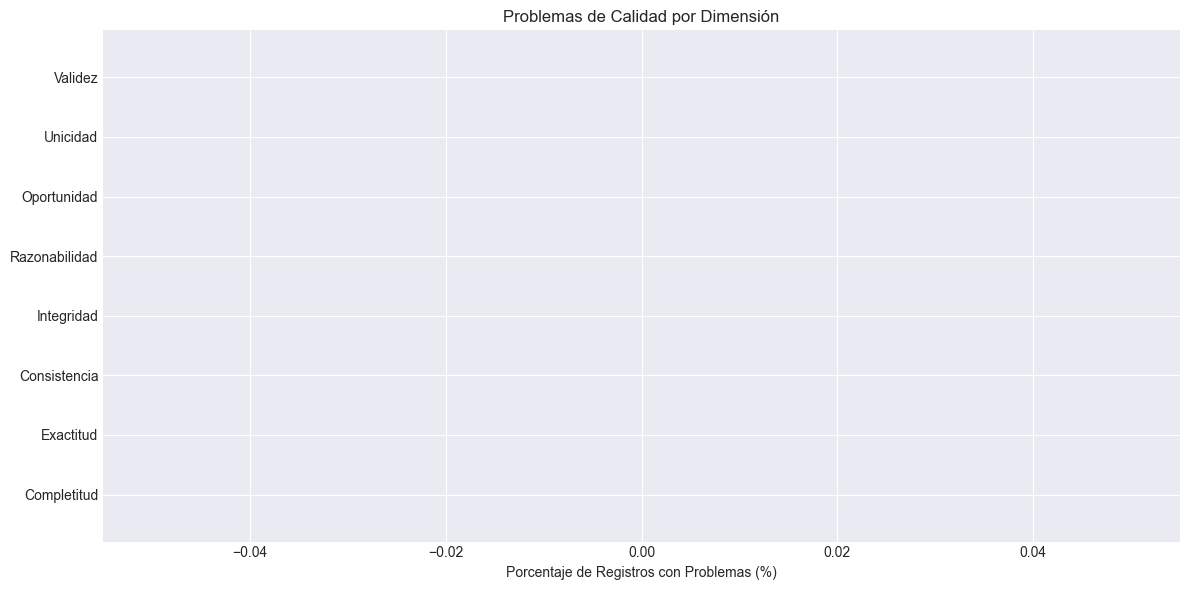

In [13]:
# Crear resumen
resumen = {
    'Dimensión': [
        'Completitud',
        'Exactitud',
        'Consistencia',
        'Integridad',
        'Razonabilidad',
        'Oportunidad',
        'Unicidad',
        'Validez'
    ],
    'Registros con Problemas': [
        missing_data.sum(),
        len(ubigeos_longitud_invalida) + len(ubigeos_no_numericos) + len(ccdd_invalidos) + len(ccpp_invalidos) + len(ccdi_invalidos) + len(tipomuni_invalidos),
        len(inconsistencias) + len(categorias_incorrectas),
        len(ids_invalidos) + len(ids_duplicados) + len(ubigeos_duplicados),
        len(cantidades_invalidas) + int(precios_extremos.sum()),
        len(fechas_futuras) + len(fechas_antiguas),
        len(duplicados_exactos),
        len(nombres_invalidos) + len(estados_invalidos)
    ]
}

df_resumen = pd.DataFrame(resumen)
df_resumen['Porcentaje'] = (df_resumen['Registros con Problemas'] / len(df)) * 100


print("RESUMEN EJECUTIVO - CALIDAD DE DATOS")
print(df_resumen.to_string(index=False))

# Visualización del resumen
plt.figure(figsize=(12, 6))
plt.barh(df_resumen['Dimensión'], df_resumen['Porcentaje'])
plt.xlabel('Porcentaje de Registros con Problemas (%)')
plt.title('Problemas de Calidad por Dimensión')
plt.tight_layout()
plt.show()